# ClimateGuard AI v3.0 - Climate Profiling (Clustering)

This notebook covers climate zone classification using clustering algorithms.

## 1. Import Libraries

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os

# Add src to path
sys.path.append(os.path.abspath(os.path.join(os.path.dirname('__file__'), '..')))

from src.models.climate_profiling import ClimateProfiler
from src.models.model_evaluation import ClusteringEvaluator

# Ensure plots are displayed inline
%matplotlib inline

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)

import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully")

Libraries imported successfully


## 2. Load Selected Features Data

In [20]:
# Load data from feature selection step
df = pd.read_csv('../data/processed/06_selected_features.csv')
print(f"Data loaded: {df.shape}")
print(f"Columns: {len(df.columns)}")

Data loaded: (119398, 84)
Columns: 84


## 3. Prepare Features for Clustering

In [21]:
# Select numerical features for clustering
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
X = df[numerical_cols].fillna(0)

print(f"Features for clustering: {len(X.columns)}")
print(f"Samples: {len(X)}")

Features for clustering: 62
Samples: 119398


## 4. Initialize Climate Profiler

In [22]:
profiler = ClimateProfiler(X)
print("Climate profiler initialized")

Climate profiler initialized


## 5. Find Optimal Number of Clusters

In [23]:
print("Finding optimal number of clusters using K-Means...")
optimal_results = profiler.find_optimal_clusters(max_clusters=10, method='kmeans')

print(f"\nOptimal number of clusters: {optimal_results['optimal_n_clusters']}")
print(f"Maximum silhouette score: {optimal_results['max_silhouette']:.4f}")

Finding optimal number of clusters using K-Means...


INFO:src.models.climate_profiling:Data preprocessed and scaled
INFO:src.models.climate_profiling:Using 10000 samples from 119398 for faster computation
INFO:src.models.climate_profiling:Testing 2 clusters...
INFO:src.models.climate_profiling:  Silhouette score: 0.1633
INFO:src.models.climate_profiling:Testing 3 clusters...
INFO:src.models.climate_profiling:  Silhouette score: 0.1456
INFO:src.models.climate_profiling:Testing 4 clusters...
INFO:src.models.climate_profiling:  Silhouette score: 0.1456
INFO:src.models.climate_profiling:Testing 5 clusters...
INFO:src.models.climate_profiling:  Silhouette score: 0.1495
INFO:src.models.climate_profiling:Testing 6 clusters...
INFO:src.models.climate_profiling:  Silhouette score: 0.1185
INFO:src.models.climate_profiling:Testing 7 clusters...
INFO:src.models.climate_profiling:  Silhouette score: 0.1319
INFO:src.models.climate_profiling:Testing 8 clusters...
INFO:src.models.climate_profiling:  Silhouette score: 0.1281
INFO:src.models.climate_profi


Optimal number of clusters: 2
Maximum silhouette score: 0.1633


## 6. K-Means Clustering

In [24]:
# Use optimal number of clusters
n_clusters = optimal_results['optimal_n_clusters']
kmeans_labels = profiler.kmeans_clustering(n_clusters=n_clusters)

print(f"K-Means clustering completed with {n_clusters} clusters")
print(f"Cluster distribution:")
print(pd.Series(kmeans_labels).value_counts().sort_index())

INFO:src.models.climate_profiling:K-Means clustering completed with 2 clusters


K-Means clustering completed with 2 clusters
Cluster distribution:
0    54723
1    64675
Name: count, dtype: int64


In [25]:
import pickle
import os
from sklearn.cluster import KMeans

# Save the K-Means model
model_dir = '../trained_models'
os.makedirs(model_dir, exist_ok=True)

kmeans_model = KMeans(n_clusters=n_clusters, random_state=42)
kmeans_model.fit(profiler.scaler.transform(X))

with open(f'{model_dir}/01_kmeans_clustering_model.pkl', 'wb') as f:
    pickle.dump(kmeans_model, f)

print(f"K-Means model saved to {model_dir}/01_kmeans_clustering_model.pkl")

# Save the scaler used for preprocessing
with open(f'{model_dir}/01_clustering_scaler.pkl', 'wb') as f:
    pickle.dump(profiler.scaler, f)

print(f"Scaler saved to {model_dir}/01_clustering_scaler.pkl")

K-Means model saved to ../trained_models/01_kmeans_clustering_model.pkl
Scaler saved to ../trained_models/01_clustering_scaler.pkl


## 7. DBSCAN Clustering  

In [26]:
dbscan_labels = profiler.dbscan_clustering(eps=0.5, min_samples=5)

print(f"DBSCAN clustering completed")
print(f"Number of clusters found: {len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)}")
print(f"Noise points: {list(dbscan_labels).count(-1)}")

INFO:src.models.climate_profiling:DBSCAN clustering completed with 73 clusters


DBSCAN clustering completed
Number of clusters found: 73
Noise points: 119004


## 8. Gaussian Mixture Clustering

In [27]:
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(n_components=n_clusters, random_state=42)
gmm_labels = gmm.fit_predict(X)

print(f"Gaussian Mixture clustering completed with {n_clusters} components")
print(f"Cluster distribution:")
print(pd.Series(gmm_labels).value_counts().sort_index())

Gaussian Mixture clustering completed with 2 components
Cluster distribution:
0    59644
1    59754
Name: count, dtype: int64


## 9. Agglomerative Clustering

In [28]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.neighbors import KNeighborsClassifier

# Perform agglomerative clustering on a sample to avoid O(n^2) memory usage,
# then propagate labels to the full dataset via k-NN.
sample_size = min(10000, len(X))
rng = np.random.RandomState(42)
sample_idx = rng.choice(len(X), size=sample_size, replace=False)
X_sample = X.iloc[sample_idx]

agg = AgglomerativeClustering(n_clusters=n_clusters, linkage='ward')
labels_sample = agg.fit_predict(X_sample)

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_sample, labels_sample)
agg_labels = knn.predict(X)

print(f"Agglomerative clustering completed with {n_clusters} clusters")
print(f"Cluster distribution:")
print(pd.Series(agg_labels).value_counts().sort_index())

Agglomerative clustering completed with 2 clusters
Cluster distribution:
0    78913
1    40485
Name: count, dtype: int64


## 10. Evaluate Clustering Results

In [29]:
# Evaluate K-Means clustering
evaluator = ClusteringEvaluator(X, kmeans_labels)
cluster_report = evaluator.generate_evaluation_report()
evaluator.print_report()

CLUSTERING EVALUATION REPORT

CLUSTERING METRICS:
  Silhouette Score: 0.5558
  Davies-Bouldin Score: 0.5715
  Calinski-Harabasz Score: 247295.97



## 11. Get Cluster Characteristics 

In [30]:
cluster_stats = profiler.get_cluster_characteristics()
print("Cluster characteristics:")
display(cluster_stats)

Cluster characteristics:


latitude            longitude           last_updated_epoch  \
              mean       std       mean       std               mean   
cluster                                                                
-1       23.096019  5.798057  80.236188  5.759470       1.702941e+09   
 0       20.384000  0.198066  85.788000  0.232314       1.693526e+09   
 1       22.588000  0.192795  88.330000  0.053385       1.693526e+09   
 2       26.073333  0.521025  79.495000  0.448453       1.693698e+09   
 3       27.254286  0.196372  79.110000  0.797412       1.693698e+09   
...            ...       ...        ...       ...                ...   
 68      27.148000  0.179639  79.972000  0.807818       1.704911e+09   
 69      22.526000  0.089610  88.312000  0.036332       1.704911e+09   
 70      22.522000  0.086429  88.324000  0.044497       1.707674e+09   
 71      27.650000  0.504183  81.388000  0.815641       1.707674e+09   
 72      22.522000  0.086429  88.324000  0.044497       1.710176e+09   

                      temperature_celsius             wind_kph            ...  \
                  std                mean       std       mean       std  ...   
cluster                                                                   ...   
-1       5.658628e+06           20.302234  6.541065   8.088585  4.539710  ...   
 0       0.000000e+00           27.000000  0.000000   6.100000  0.000000  ...   
 1       0.000000e+00           29.000000  0.000000   6.100000  0.000000  ...   
 2       0.000000e+00           28.983333  0.470815  10.500000  0.428952  ...   
 3       0.000000e+00           27.971429  0.475094  11.071429  0.275162  ...   
...               ...                 ...       ...        ...       ...  ...   
 68      0.000000e+00           10.740000  0.089443  12.440000  0.357771  ...   
 69      0.000000e+00           19.000000  0.000000   3.600000  0.000000  ...   
 70      0.000000e+00           20.000000  0.000000   3.600000  0.000000  ...   
 71      0.000000e+00           14.060000  0.054772   7.840000  0.134164  ...   
 72      0.000000e+00           26.000000  0.000000  13.000000  0.000000  ...   

         hour_sin            hour_cos              minute_sin          \
             mean       std      mean       std          mean     std   
cluster                                                                 
-1       0.080925  0.488977  0.836710  0.232963  5.998118e-02  0.6919   
 0       0.965926  0.000000  0.258819  0.000000  1.000000e+00  0.0000   
 1       0.965926  0.000000  0.258819  0.000000  1.000000e+00  0.0000   
 2       0.965926  0.000000  0.258819  0.000000  1.000000e+00  0.0000   
 3       0.965926  0.000000  0.258819  0.000000  1.000000e+00  0.0000   
...           ...       ...       ...       ...           ...     ...   
 68      0.000000  0.000000  1.000000  0.000000  0.000000e+00  0.0000   
 69      0.000000  0.000000  1.000000  0.000000  0.000000e+00  0.0000   
 70     -0.258819  0.000000  0.965926  0.000000  1.000000e+00  0.0000   
 71     -0.258819  0.000000  0.965926  0.000000  1.000000e+00  0.0000   
 72     -0.500000  0.000000  0.866025  0.000000  5.665539e-16  0.0000   

           minute_cos            uv_alert            
                 mean       std      mean       std  
cluster                                              
-1       7.629996e-03  0.719462  0.000042  0.006482  
 0       2.832769e-16  0.000000  0.000000  0.000000  
 1       2.832769e-16  0.000000  0.000000  0.000000  
 2       2.832769e-16  0.000000  0.000000  0.000000  
 3       2.832769e-16  0.000000  0.000000  0.000000  
...               ...       ...       ...       ...  
 68      1.000000e+00  0.000000  0.000000  0.000000  
 69      1.000000e+00  0.000000  0.000000  0.000000  
 70      2.832769e-16  0.000000  0.000000  0.000000  
 71      2.832769e-16  0.000000  0.000000  0.000000  
 72     -1.000000e+00  0.000000  0.000000  0.000000  

[74 rows x 124 columns]

## 12. Add Cluster Labels to Dataset

In [31]:
# Use K-Means labels as final clusters
df['climate_zone'] = kmeans_labels

print(f"Added climate zone labels to dataset")
print(f"Climate zone distribution:")
print(df['climate_zone'].value_counts().sort_index())

Added climate zone labels to dataset
Climate zone distribution:
climate_zone
0    54723
1    64675
Name: count, dtype: int64


## 13. Analyze Climate Zones

In [32]:
# Group by climate zone and analyze
zone_analysis = df.groupby('climate_zone')[numerical_cols].agg(['mean', 'std'])
print("Climate zone analysis:")
display(zone_analysis)

Climate zone analysis:


latitude            longitude           last_updated_epoch  \
                   mean       std       mean       std               mean   
climate_zone                                                                
0             23.212373  5.755153  80.182745  5.758780       1.707992e+09   
1             23.004217  5.819916  80.300075  5.766888       1.698665e+09   

                           temperature_celsius            wind_kph            \
                       std                mean       std      mean       std   
climate_zone                                                                   
0             3.122666e+06           19.693505  7.496301  8.674263  4.687019   
1             3.316662e+06           20.820042  5.549716  7.597115  4.349102   

              ...  hour_sin            hour_cos           minute_sin  \
              ...      mean       std      mean       std       mean   
climate_zone  ...                                                      
0             ... -0.342193  0.239100  0.904354  0.088767   0.033971   
1             ...  0.439153  0.336533  0.779103  0.294774   0.081948   

                       minute_cos            uv_alert            
                   std       mean       std      mean       std  
climate_zone                                                     
0             0.694707  -0.015606  0.718333  0.000000  0.000000  
1             0.688838   0.026765  0.719782  0.000077  0.008792  

[2 rows x 124 columns]

## 14. Visualize Climate Zones

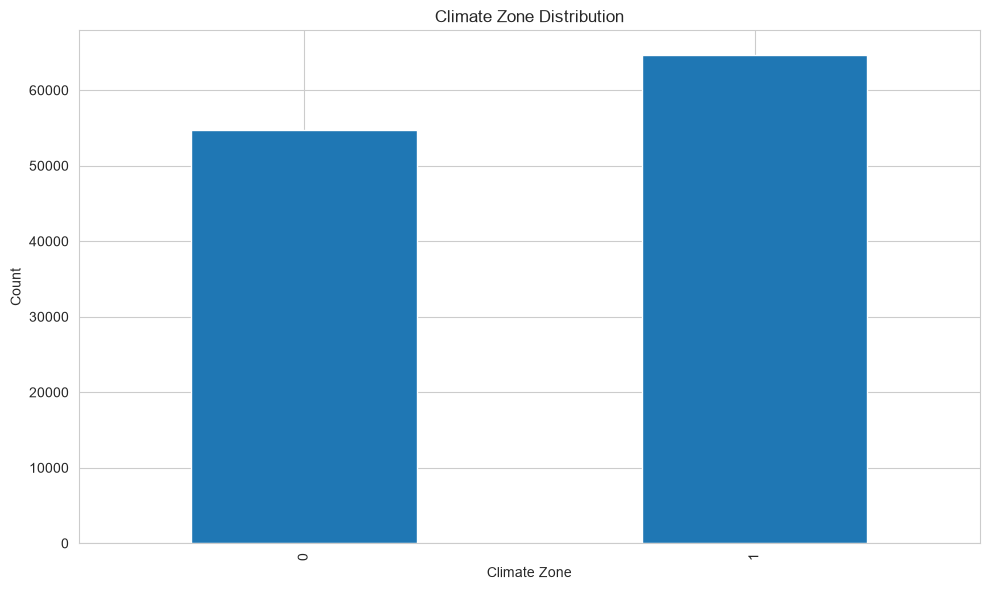

Climate zone distribution plot displayed


In [33]:
# Plot cluster distribution
plt.figure(figsize=(10, 6))
df['climate_zone'].value_counts().sort_index().plot(kind='bar')
plt.title('Climate Zone Distribution')
plt.xlabel('Climate Zone')
plt.ylabel('Count')
plt.tight_layout()
plt.show()
print("Climate zone distribution plot displayed")

## 15. Print Clustering Report

In [34]:
# def print_report(self):
#     """Print the Climate Profiling Report with clustering evaluation results."""

#     print("=" * 80)
#     print("CLIMATE PROFILING REPORT")
#     print("=" * 80)

#     # Optimal cluster results
#     print("\nOPTIMAL_CLUSTERS:")

#     # ------------------------------------------------------------
#     # K-MEANS RESULTS
#     # ------------------------------------------------------------
#     if hasattr(self, "kmeans_results") and self.kmeans_results is not None:

#         kmeans = self.kmeans_results

#         print("\nKMEANS:")

#         # Number of clusters
#         n_clusters = kmeans.get("n_clusters")
#         print(
#             f"  Number of clusters: {n_clusters}"
#             if n_clusters is not None
#             else "  Number of clusters: N/A"
#         )

#         # Silhouette Score
#         silhouette = kmeans.get("silhouette_score")
#         print(
#             f"  Silhouette Score: {silhouette:.4f}"
#             if silhouette is not None
#             else "  Silhouette Score: N/A"
#         )

#         # Davies-Bouldin Score
#         davies_bouldin = kmeans.get("davies_bouldin_score")
#         print(
#             f"  Davies-Bouldin Score: {davies_bouldin:.4f}"
#             if davies_bouldin is not None
#             else "  Davies-Bouldin Score: N/A"
#         )

#         # Calinski-Harabasz Score
#         calinski_harabasz = kmeans.get("calinski_harabasz_score")
#         print(
#             f"  Calinski-Harabasz Score: {calinski_harabasz:.2f}"
#             if calinski_harabasz is not None
#             else "  Calinski-Harabasz Score: N/A"
#         )

#     else:
#         print("\nKMEANS:")
#         print("  No K-Means results available.")

#     # ------------------------------------------------------------
#     # DBSCAN RESULTS
#     # ------------------------------------------------------------
#     if hasattr(self, "dbscan_results") and self.dbscan_results is not None:

#         dbscan = self.dbscan_results

#         print("\nDBSCAN:")

#         # Number of clusters
#         n_clusters = dbscan.get("n_clusters")
#         print(
#             f"  Number of clusters: {n_clusters}"
#             if n_clusters is not None
#             else "  Number of clusters: N/A"
#         )

#         # Silhouette Score
#         silhouette = dbscan.get("silhouette_score")
#         print(
#             f"  Silhouette Score: {silhouette:.4f}"
#             if silhouette is not None
#             else "  Silhouette Score: N/A"
#         )

#         # Davies-Bouldin Score
#         davies_bouldin = dbscan.get("davies_bouldin_score")
#         print(
#             f"  Davies-Bouldin Score: {davies_bouldin:.4f}"
#             if davies_bouldin is not None
#             else "  Davies-Bouldin Score: N/A"
#         )

#         # Calinski-Harabasz Score
#         calinski_harabasz = dbscan.get("calinski_harabasz_score")
#         print(
#             f"  Calinski-Harabasz Score: {calinski_harabasz:.2f}"
#             if calinski_harabasz is not None
#             else "  Calinski-Harabasz Score: N/A"
#         )

#     else:
#         print("\nDBSCAN:")
#         print("  No DBSCAN results available.")

#     print("\n" + "=" * 80)

In [35]:
# profiler.print_report()

## 16. Save Data with Climate Zones  

In [36]:
df.to_csv('../data/processed/07_climate_zones.csv', index=False)
print("\nData with climate zones saved to ../data/processed/07_climate_zones.csv")


Data with climate zones saved to ../data/processed/07_climate_zones.csv


## Summary

In this notebook, we:
1. Loaded the selected features data
2. Found optimal number of clusters using elbow method
3. Applied K-Means clustering
4. Applied DBSCAN clustering
5. Applied Gaussian Mixture clustering
6. Applied Agglomerative clustering
7. Evaluated clustering results using metrics
8. Analyzed cluster characteristics
9. Added climate zone labels to dataset
10. Visualized climate zone distribution
11. Saved data with climate zones for prediction models
12. **Saved K-Means model and scaler as .pkl files for integration with app.py**

Next: Rainfall Prediction